# 🚀Cloud-Based Jupyter Environment & ML Pipeline

## Step 1 — Verify GPU Runtime 🖥️
Go to **Runtime → Change runtime type → T4 GPU**, then run the cell below.

In [5]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU detected: {gpus[0].name}")
    tf.config.experimental.set_memory_growth(gpus[0], True)
else:
    print("⚠️  No GPU found. Running on CPU — still fine for this lab.")


✅ GPU detected: /physical_device:GPU:0


## Step 2 — Mount Google Drive 📂
This lets us save files permanently. A browser pop-up will ask you to authorise.

In [6]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted at /content/drive")


Mounted at /content/drive
✅ Google Drive mounted at /content/drive


## Step 3 — Install Extra Libraries 📦

In [7]:
!pip install -q yellowbrick

import yellowbrick
print(f"✅ yellowbrick {yellowbrick.__version__} ready")


✅ yellowbrick 1.5 ready


## Step 4 — Import All Libraries

In [8]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc

from yellowbrick.classifier import ClassificationReport

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

print("✅ All libraries imported")


✅ All libraries imported


## Step 5 — Load the Iris Dataset 🌸

In [9]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print(f"Dataset shape : {df.shape}  ({df.shape[0]} samples, {df.shape[1]-1} features + 1 target)")
print(f"Species       : {list(df['species'].unique())}")
df.head()


Dataset shape : (150, 5)  (150 samples, 4 features + 1 target)
Species       : ['setosa', 'versicolor', 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [10]:
print("── Class distribution ──")
print(df['species'].value_counts().to_string())
print()
print("── Descriptive statistics ──")
df.describe().round(2)


── Class distribution ──
species
setosa        50
versicolor    50
virginica     50

── Descriptive statistics ──


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


## Step 6 — Exploratory Visualisations 📊
### Figure 1 — Pairplot (feature relationships by species)

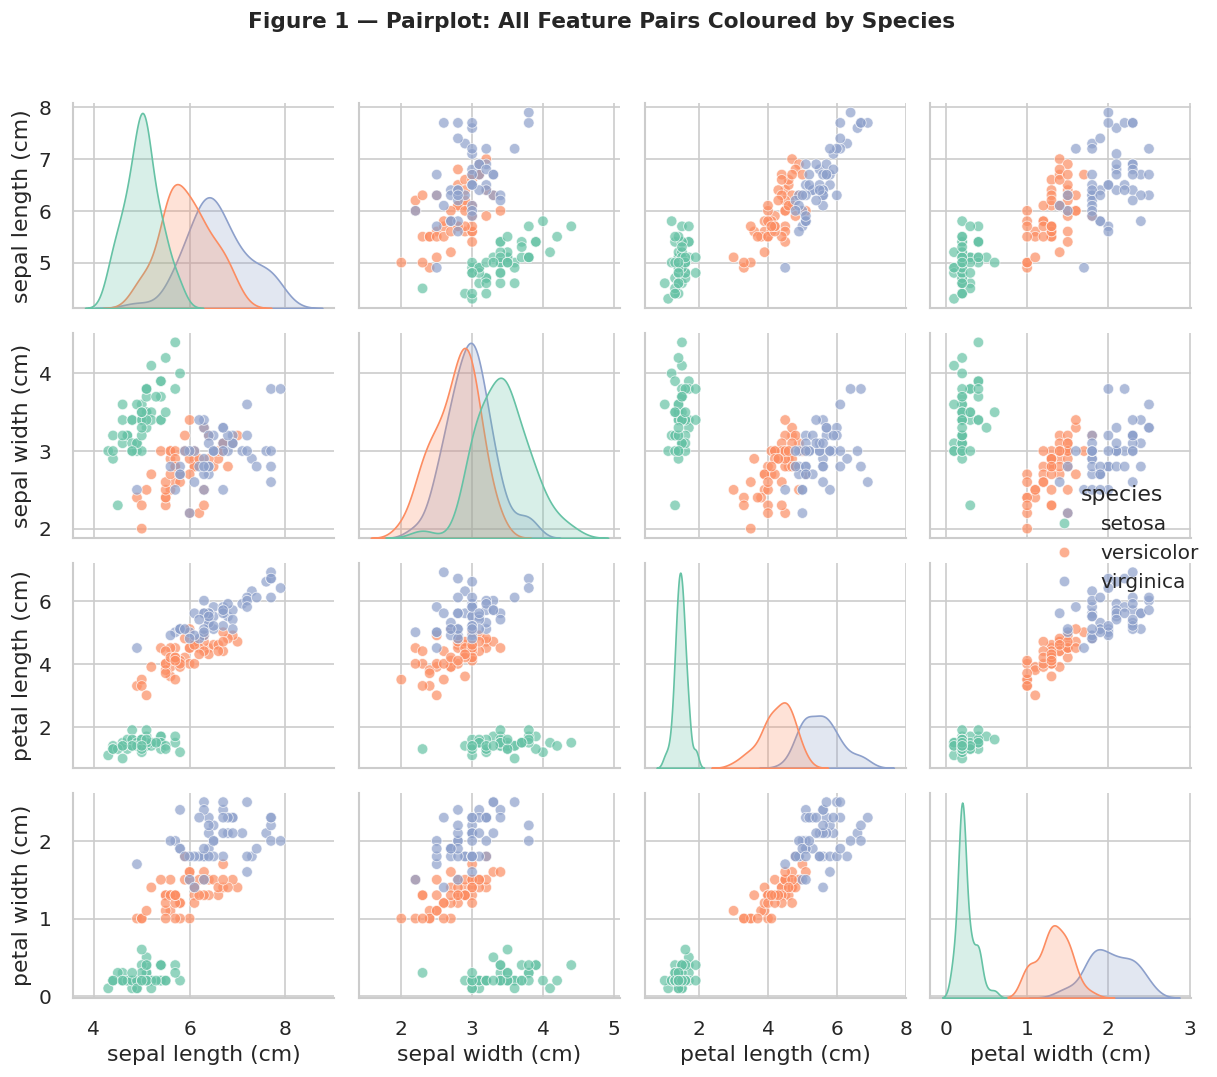

✅ Saved fig1_pairplot.png


In [11]:
g = sns.pairplot(df, hue="species", height=2.2, plot_kws={"alpha": 0.7, "s": 40})
g.fig.suptitle("Figure 1 — Pairplot: All Feature Pairs Coloured by Species",
               y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig1_pairplot.png", bbox_inches="tight")
plt.show()
print("✅ Saved fig1_pairplot.png")


### Figure 2 — Box Plots (feature distributions per species)

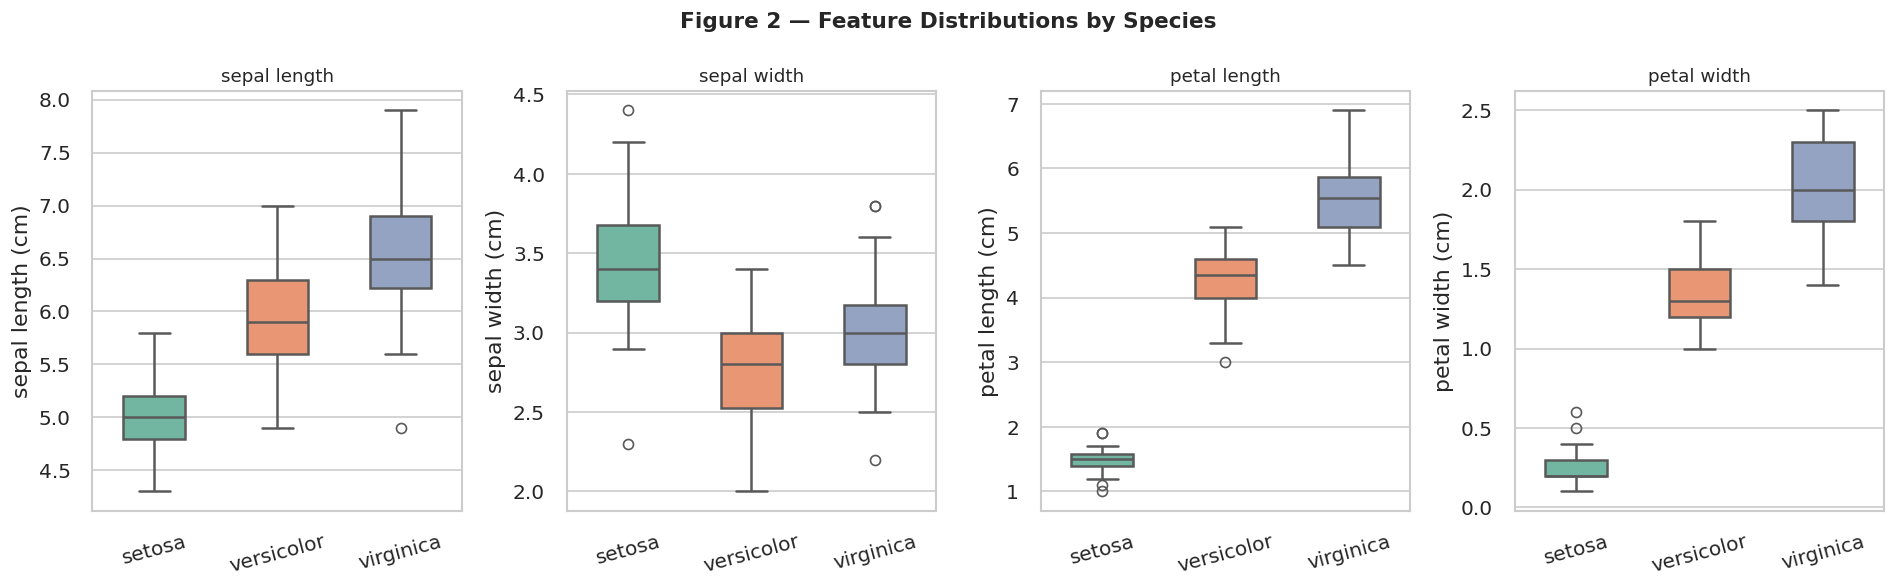

✅ Saved fig2_boxplots.png


In [12]:
features = iris.feature_names
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)
palette = sns.color_palette("Set2", 3)

for ax, feat in zip(axes, features):
    sns.boxplot(data=df, x="species", y=feat, palette=palette,
                width=0.5, linewidth=1.5, ax=ax)
    ax.set_title(feat.replace(" (cm)", ""), fontsize=11)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=15)

fig.suptitle("Figure 2 — Feature Distributions by Species", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig2_boxplots.png", bbox_inches="tight")
plt.show()
print("✅ Saved fig2_boxplots.png")


### Figure 3 — Violin Plots (distribution shape + box inside)

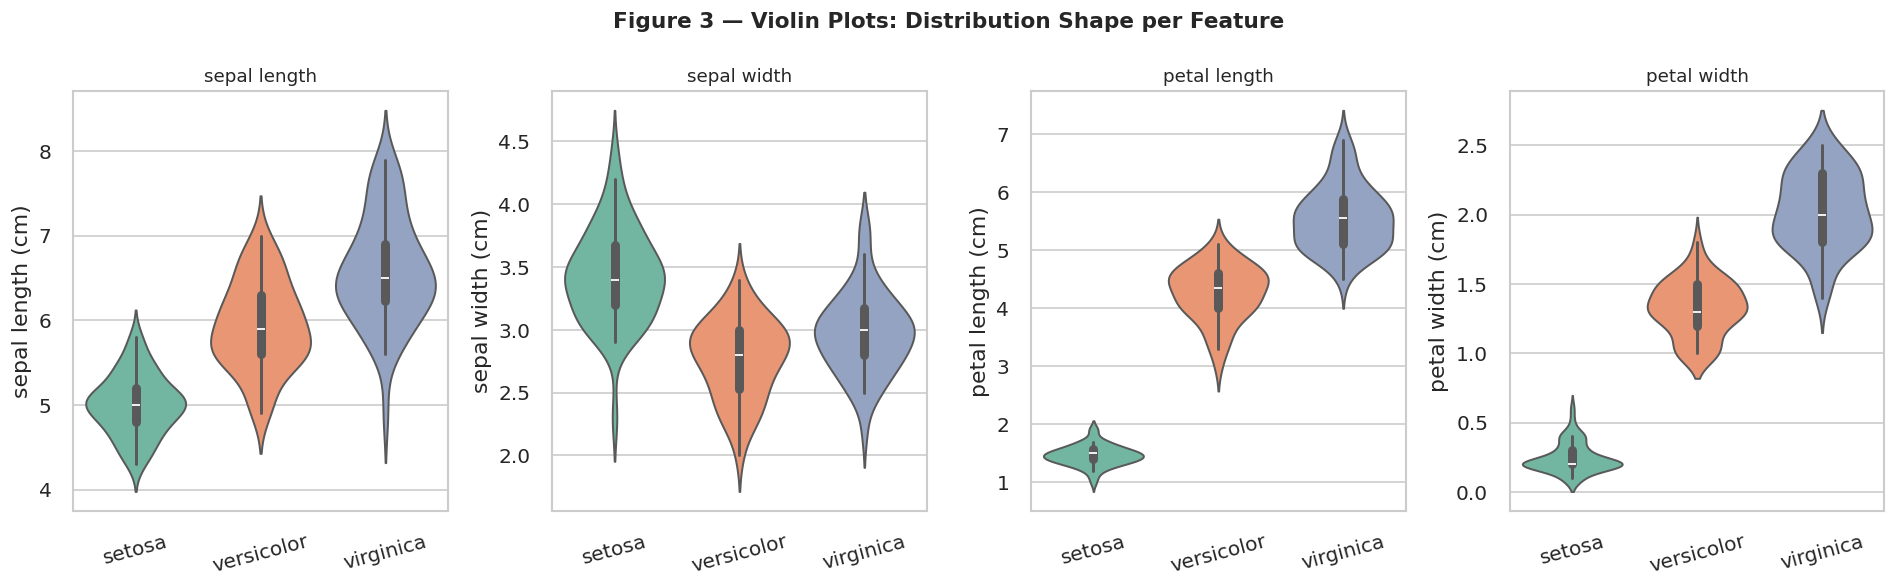

✅ Saved fig3_violin.png


In [13]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, feat in zip(axes, features):
    sns.violinplot(data=df, x="species", y=feat, palette="Set2",
                   inner="box", linewidth=1.2, ax=ax)
    ax.set_title(feat.replace(" (cm)", ""), fontsize=11)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=15)

fig.suptitle("Figure 3 — Violin Plots: Distribution Shape per Feature", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig3_violin.png", bbox_inches="tight")
plt.show()
print("✅ Saved fig3_violin.png")


### Figure 4 — Correlation Heatmap

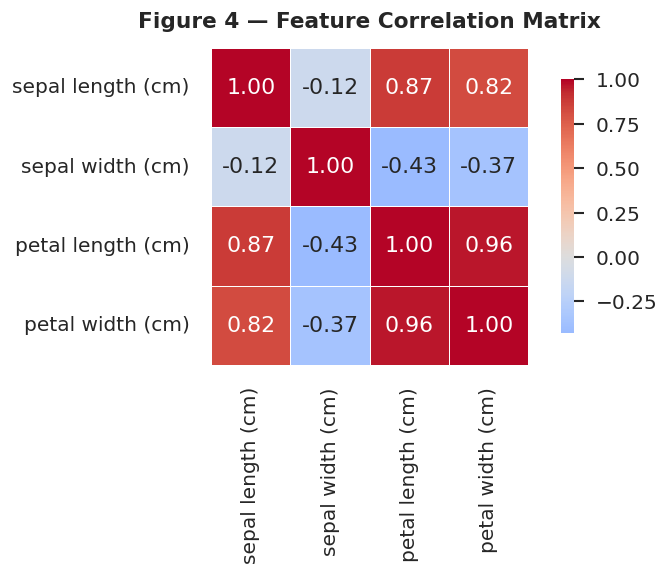

✅ Saved fig4_heatmap.png


In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)

ax.set_title("Figure 4 — Feature Correlation Matrix", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("fig4_heatmap.png", bbox_inches="tight")
plt.show()
print("✅ Saved fig4_heatmap.png")


## Step 7 — Build & Train the Model 🤖

In [15]:
X = df[features]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train size : {len(X_train)}")
print(f"Test  size : {len(X_test)}")


Train size : 120
Test  size : 30


In [16]:
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print("✅ Training complete")


✅ Training complete


## Step 8 — Evaluate Performance 📈

In [17]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy : {accuracy * 100:.2f}%\n")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


Overall Accuracy : 90.00%

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



### Figure 5 — Confusion Matrix

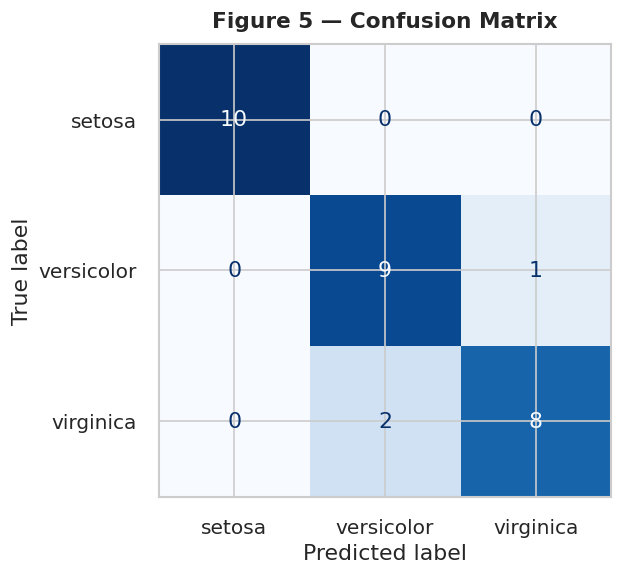

✅ Saved fig5_confusion_matrix.png


In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred, labels=iris.target_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap="Blues", colorbar=False, ax=ax)
ax.set_title("Figure 5 — Confusion Matrix", fontsize=13, fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig("fig5_confusion_matrix.png", bbox_inches="tight")
plt.show()
print("✅ Saved fig5_confusion_matrix.png")


### Figure 6 — Feature Importance

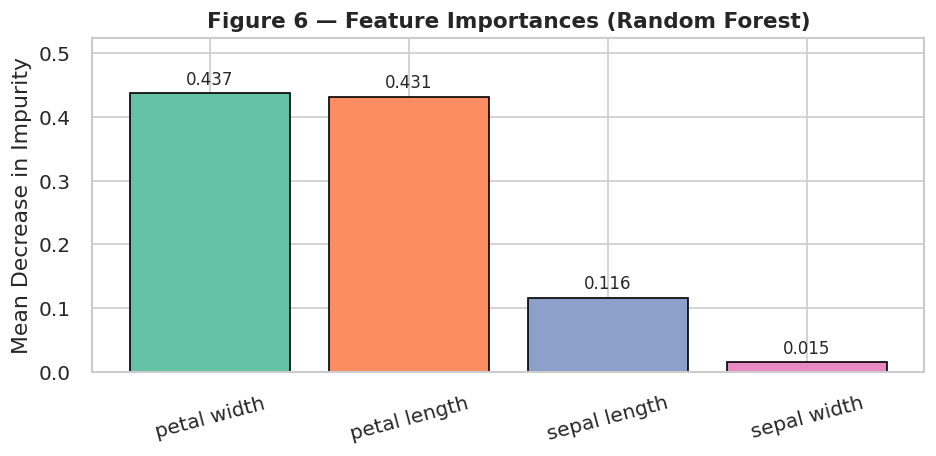

✅ Saved fig6_feature_importance.png


In [19]:
importances = model.feature_importances_
short_names = [f.replace(" (cm)", "") for f in features]
order = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(4), importances[order], color=sns.color_palette("Set2", 4), edgecolor="black")
ax.set_xticks(range(4))
ax.set_xticklabels([short_names[i] for i in order], rotation=15)
ax.set_ylabel("Mean Decrease in Impurity")
ax.set_title("Figure 6 — Feature Importances (Random Forest)", fontsize=13, fontweight="bold")
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=10)
ax.set_ylim(0, max(importances) * 1.2)
plt.tight_layout()
plt.savefig("fig6_feature_importance.png", bbox_inches="tight")
plt.show()
print("✅ Saved fig6_feature_importance.png")


### Figure 7 — Learning Curve

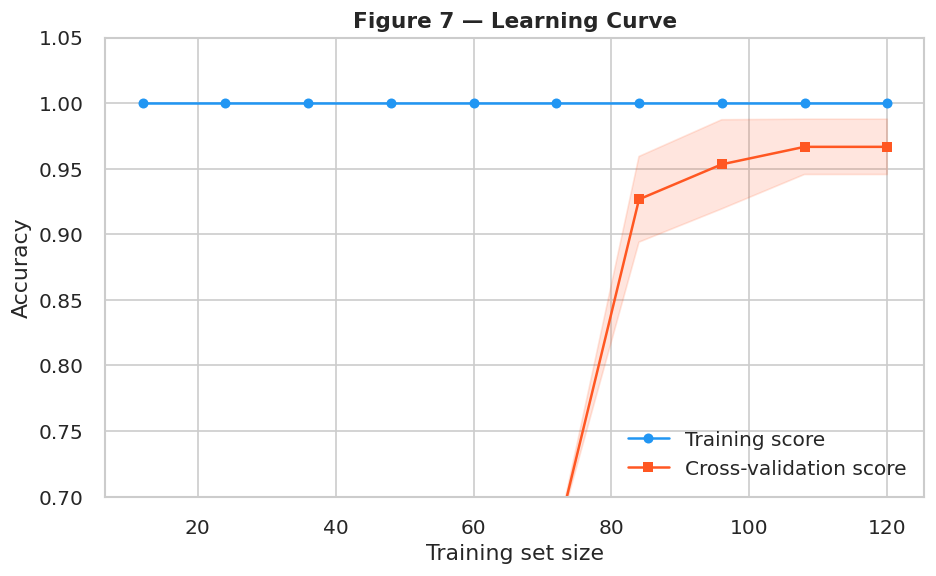

✅ Saved fig7_learning_curve.png


In [20]:
train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X, y, cv=5, scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_mean, "o-", color="#2196F3", label="Training score")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="#2196F3")
ax.plot(train_sizes, val_mean, "s-", color="#FF5722", label="Cross-validation score")
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color="#FF5722")
ax.set_xlabel("Training set size")
ax.set_ylabel("Accuracy")
ax.set_title("Figure 7 — Learning Curve", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
ax.set_ylim(0.7, 1.05)
plt.tight_layout()
plt.savefig("fig7_learning_curve.png", bbox_inches="tight")
plt.show()
print("✅ Saved fig7_learning_curve.png")


### Figure 8 — ROC Curves (One-vs-Rest)

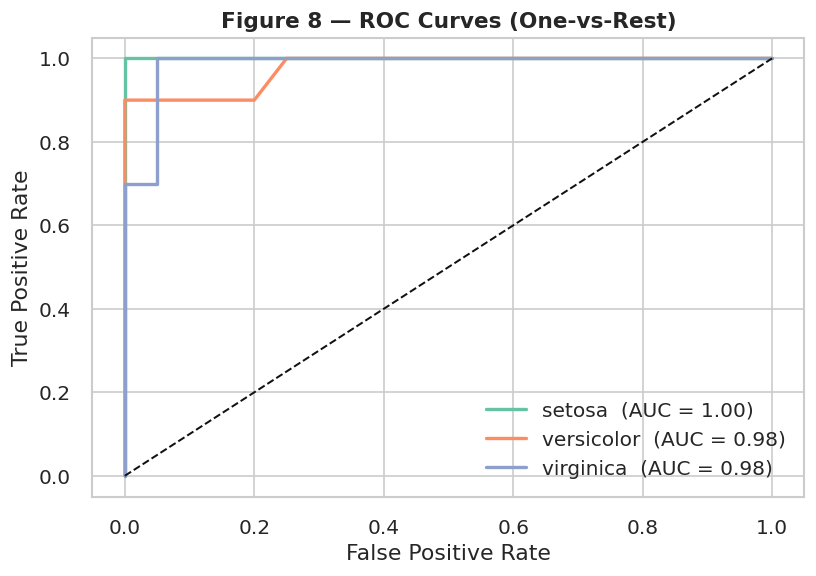

✅ Saved fig8_roc_curves.png


In [21]:
y_bin = label_binarize(y, classes=iris.target_names)
ovo_model = OneVsRestClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
ovo_model.fit(X_train, label_binarize(y_train, classes=iris.target_names))
y_score = ovo_model.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=iris.target_names)

colors = sns.color_palette("Set2", 3)
fig, ax = plt.subplots(figsize=(7, 5))

for i, (cls, color) in enumerate(zip(iris.target_names, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{cls}  (AUC = {roc_auc:.2f})")

ax.plot([0, 1], [0, 1], "k--", lw=1.2)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Figure 8 — ROC Curves (One-vs-Rest)", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("fig8_roc_curves.png", bbox_inches="tight")
plt.show()
print("✅ Saved fig8_roc_curves.png")


## Step 9 — Save Model to Google Drive 💾

In [22]:
save_folder = '/content/drive/MyDrive/DS_Lab_Week7'
os.makedirs(save_folder, exist_ok=True)

model_path = os.path.join(save_folder, 'iris_rf_model.pkl')
joblib.dump(model, model_path)

print(f"✅ Model saved → {model_path}")
!ls -lh "{save_folder}"


✅ Model saved → /content/drive/MyDrive/DS_Lab_Week7/iris_rf_model.pkl
total 165K
-rw------- 1 root root 165K Apr 23 10:37 iris_rf_model.pkl


## Step 10 — Load Model & Predict on New Data 🔮

In [23]:
loaded_model = joblib.load(model_path)
print("✅ Model loaded from Drive")

new_flower = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=features)
prediction   = loaded_model.predict(new_flower)[0]
probabilities = loaded_model.predict_proba(new_flower)[0]

print(f"\nMeasurements : {new_flower.values[0].tolist()}")
print(f"Prediction   : {prediction}")

print("\nConfidence per species:")
for cls, p in zip(loaded_model.classes_, probabilities):
    bar = "█" * int(p * 30)
    print(f"  {cls:15s}  {bar:<30s}  {p*100:5.1f}%")


✅ Model loaded from Drive

Measurements : [5.1, 3.5, 1.4, 0.2]
Prediction   : setosa

Confidence per species:
  setosa           ██████████████████████████████  100.0%
  versicolor                                         0.0%
  virginica                                          0.0%


### Figure 9 — Prediction Confidence Bar Chart

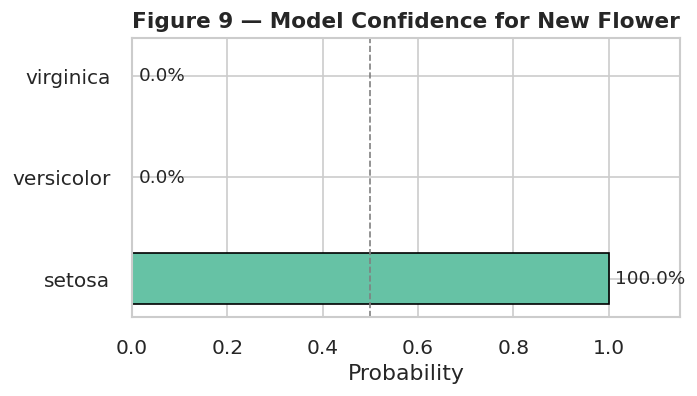

✅ Saved fig9_prediction_confidence.png


In [24]:
fig, ax = plt.subplots(figsize=(6, 3.5))
colors_pred = [sns.color_palette("Set2", 3)[i] for i in range(3)]
bars = ax.barh(loaded_model.classes_, probabilities, color=colors_pred, edgecolor="black", height=0.5)
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=11,
             labels=[f"{p*100:.1f}%" for p in probabilities])
ax.set_xlim(0, 1.15)
ax.set_xlabel("Probability")
ax.set_title("Figure 9 — Model Confidence for New Flower", fontsize=13, fontweight="bold")
ax.axvline(0.5, color="grey", linestyle="--", linewidth=1)
plt.tight_layout()
plt.savefig("fig9_prediction_confidence.png", bbox_inches="tight")
plt.show()
print("✅ Saved fig9_prediction_confidence.png")


In [25]:
print("congratulations you completed lab 🎉")

congratulations you completed lab 🎉
